## **Parte práctica, examen 1: Morfología de galaxias y la posición del Sol en la Vía Láctea**

**Curso:** Astrofísica Galáctica y Extragaláctica

**Estudiante:** Bryan Camilo Restrepo Arcila

**Profesor**: Juan Carlos Muñoz Cuartas


**Fecha**: 2026-10-06

**Universidad de Antioquia**

----


##### Instalando las librerías


In [21]:
!pip -q install astropy numpy matplotlib scipy 

##### Importando las librerias

In [22]:
import os
import urllib.request
import re
from collections import OrderedDict
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from astropy.io import fits
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Circle, Ellipse, Patch
from scipy.ndimage import binary_erosion, gaussian_filter, label, map_coordinates


##### Datos

Todos los archivos estan disponibles en el repositorio de github de este curso:

https://github.com/andromedalactea/galacticAndExtraGalacticAstrophysics


In [23]:
# Misma ruta relativa que el resto del cuaderno: data/ junto al directorio de trabajo.
# Solo archivos que el código abre. NGC 4254 todavía no está en main; la ruta queda lista.
BASE = "https://raw.githubusercontent.com/andromedalactea/galacticAndExtraGalacticAstrophysics/main/Exam%201/data"
destino = Path(os.getcwd()) / "data"
destino.mkdir(parents=True, exist_ok=True)
archivos = [
    "NGC_2403_beta_g.fits",
    "NGC2403_Rot_Curve.dat",
    "NGC628_g.fits",
    "NGC4254_g.fits",
    "NGC3379_g.fits",
    "NGC4374_g.fits",
    "GCs_MW.csv",
    "disquito.dat",
]
for nombre in archivos:
    ruta = destino / nombre
    if ruta.exists() and ruta.stat().st_size > 0:
        print(f"ya está: {ruta.name}")
        continue
    print(f"descargando {nombre}")
    urllib.request.urlretrieve(f"{BASE}/{nombre}", ruta)

figuras = Path(os.getcwd()) / "figuras"
figuras.mkdir(parents=True, exist_ok=True)
nombre_figura = "pipeline_isofotas.png"
ruta_figura = figuras / nombre_figura
if ruta_figura.exists() and ruta_figura.stat().st_size > 0:
    print(f"ya está: {ruta_figura.name}")
else:
    print(f"descargando {nombre_figura}")
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/andromedalactea/galacticAndExtraGalacticAstrophysics/main/Exam%201/figuras/pipeline_isofotas.png",
        ruta_figura,
    )


ya está: NGC_2403_beta_g.fits
ya está: NGC2403_Rot_Curve.dat
ya está: NGC628_g.fits
ya está: NGC4254_g.fits
ya está: NGC3379_g.fits
ya está: NGC4374_g.fits
ya está: GCs_MW.csv
ya está: disquito.dat
ya está: pipeline_isofotas.png


##### Variables

In [24]:
# Espesor de un disco visto de canto. 
Q0 = 0.2
# Magnitud de un nanomaggy.
CERO_AB = 22.5
# 2.5 / ln(10). Carroll lo escribe 1.09.
FACTOR_MAG = 2.5 / np.log(10)
# Recta de Tully-Fisher en B para una Sc. Carroll no da el caso Scd.
# M(B) = -11.0 + 3.31\log_{10} V.
TF_SC = (-11.0, 3.31)
# Exponente gamma de la ley de masa-luminosidad, típico para galaxias espirales
GAMMA = 1.5

### Ejercicio 1

Se provee una curva de rotación de la galaxia NGC2403. Además de esta curva, utilice un repositorio de imágenes astronómicas para obtener una imagen de la galaxia NGC2403 (mi recomendación es usar la banda g de SDSS).

Sólo puede usar la curva de rotación que se provee y la imagen que consiga descargar desde los archivos.

Utilice un trazado de isofotas, ajuste de elipses a las mismas, etc. Con esos trazados de isofotas, diseñe métodos o use métodos ya conocidos para que:

- Defina como va a ubicar el centro de la galaxia.
- Estime la inclinación de la galaxia
- Mida la distribución de brillo superficial de la galaxia (I(R)) y úsela para identificar la región donde inicia el bulbo y donde termina el disco (zona de intersección).
- Haga una estimación a la clasificación de la galaxia en el sistema de Hubble.
- Trate de identificar los brazos espirales de la galaxia y proponga una manera de estimar sobre la imagen una medición del Pitch Angle (PA) de los brazos. Úsela y mida el PA de la galaxia.
- Use la información que se provee para estimar la distancia a la que se encuentra la galaxia
- Estime la escala radial del disco en Kpc.

Justifique el procedimiento por medio del cual midió/estimó cada uno de los ítems requeridos.

----


##### Leyendo los datos:

La imagen de NGC 2403 utilizada en este trabajo corresponde a la banda g del archivo "NGC_2403_beta_g.fits", la cual fue obtenida del repositorio público de la Monash University https://store.erc.monash.edu.au/dataset/417

In [25]:
# Leyendo los datos para ngc2403
CARPETA = Path(os.getcwd())
RUTA_IMAGEN = CARPETA / "data" / "NGC_2403_beta_g.fits"
RUTA_CURVA = CARPETA / "data" / "NGC2403_Rot_Curve.dat"
CARPETA_FIGURAS = CARPETA / "figuras"


with fits.open(RUTA_IMAGEN) as hdul:
    imagen = hdul[0].data.astype(float)
    cabecera = hdul[0].header
# Arco equivalente a lo que ocupa la imagen en el cielo en segundos de arco
escala = abs(cabecera["CD1_1"]) * 3600.0    
curva_r, curva_v  = np.loadtxt(RUTA_CURVA, unpack=True)


def limpiar(imagen):
    """Resta el cielo (media del borde) y tapa las estrellas."""
    borde = np.concatenate(
        [imagen[:40].ravel(), imagen[-40:].ravel(), imagen[:, :40].ravel(), imagen[:, -40:].ravel()]
    )
    mediana = np.median(borde)
    sigma = 1.4826 * np.median(np.abs(borde - mediana))
    cielo = borde[np.abs(borde - mediana) < 3 * sigma].mean()
    resta = imagen - cielo
    suave = gaussian_filter(resta, 6)
    estrellas = (resta - suave) > 8 * sigma
    resta = resta.copy()
    resta[estrellas] = suave[estrellas]
    return resta, cielo, sigma

limpia, cielo, sigma = limpiar(imagen)
print("\n===== Cielo y ruido =====")
print(f"Cielo:  {cielo:.4f} nanomaggies/pixel")
print(f"Sigma:  {sigma:.4f} nanomaggies/pixel")
print("========================\n")


===== Cielo y ruido =====
Cielo:  0.0106 nanomaggies/pixel
Sigma:  0.0161 nanomaggies/pixel



##### El valor de "Cielo" indica el brillo promedio del fondo en la imagen, es decir, la luz del cielo que hay que restar. "Sigma" representa el nivel típico de ruido o variación aleatoria en ese fondo.

##### Imagen antes y después de quitar el cielo

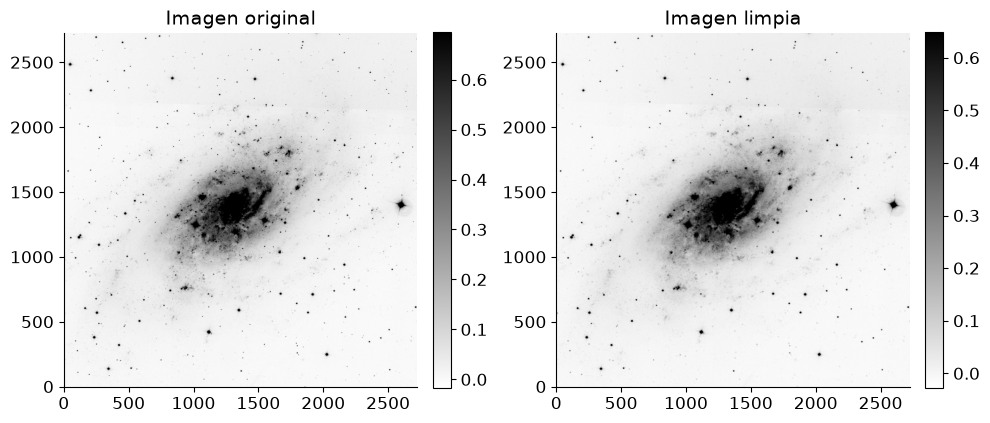

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 10))

# Selecciona percentiles para reescalar visualmente
vmin, vmax = np.percentile(imagen, [1, 99])
vmin_limpia, vmax_limpia = np.percentile(limpia, [1, 99])

# Imagen original 
ax = axes[0]
im0 = ax.imshow(imagen, origin="lower", cmap="gray_r", vmin=vmin, vmax=vmax)
ax.set_title("Imagen original")
fig.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

# Imagen limpia 
ax = axes[1]
im1 = ax.imshow(limpia, origin="lower", cmap="gray_r", vmin=vmin_limpia, vmax=vmax_limpia)
ax.set_title("Imagen limpia")
fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

##### Nanomaggie



La imagen guarda el flujo en nanomaggies, la unidad del sistema AB de SDSS **(York et al., 2000)**. El cero de ese sistema viene de **Oke y Gunn (1983)**: un flujo de 1 nanomaggie tiene magnitud

$$
m = 22.5.
$$

Con un flujo $F$ cualquiera,

$$
m = 22.5 - 2.5\log_{10} F.
$$

Ese 22.5 es la magnitud de 1 nanomaggie. Para el brillo superficial se divide por el área del píxel en segundos de arco cuadrados, y entonces $\mu = 22.5$ corresponde a 1 nanomaggie en $1''\times 1''$.

#### Centro de la galaxia


##### Cómo se obtienen las isofotas

La isofota es el borde de lo que brilla más que un nivel.

![Proceso para sacar las isofotas](figuras/pipeline_isofotas.png)

- **Estrellas.** Si un pixel pasa de $8\sigma$ sobre el fondo suave, se cambia por ese fondo.
- **Suavizar.** Promedio con los vecinos para que el borde no salte.
- **10 niveles.** Del percentil 5 al 90, parejos en logaritmo.
- **Mancha.** En cada nivel se pinta lo más brillante que el corte y se queda la mancha con más pixeles.
 - **Elipse.** Para cada mancha, se selecciona la más grande de los píxeles que están por encima de un nivel de brillo dado. Se toman todas las coordenadas de los puntos que forman esa mancha y se calcula su centro geométrico (el promedio de sus posiciones). A continuación, se calculan las distancias de cada uno de estos puntos respecto a ese centro, lo que permite construir una matriz de dispersión:
 
 $$
 \mathbf{S} = \begin{bmatrix}
     \langle (x - \bar{x})^2 \rangle & \langle (x - \bar{x})(y - \bar{y}) \rangle \\
     \langle (x - \bar{x})(y - \bar{y}) \rangle & \langle (y - \bar{y})^2 \rangle
 \end{bmatrix}
 $$
 
 Los eigenvalores y eigenvectores de esta matriz representan, respectivamente, las magnitudes ($\lambda$) y las direcciones de los semiejes mayor y menor de la elipse que mejor ajusta la mancha. Así, el tamaño de los semiejes viene dado por $2\sqrt{\lambda}$ y la orientación está dada por el eigenvector correspondiente. Eso sale del segundo momento de una elipse llena y de brillo parejo. Si el semieje mayor mide $a$, la dispersión de los píxeles a lo largo de ese eje es $\langle x^2\rangle = a^2/4$. El eigenvalor $\lambda$ es esa dispersión, así que $a = 2\sqrt{\lambda}$. El eigenvector es la dirección en la que esa dispersión es máxima: el eje mayor. Este procedimiento se repite para todas las manchas encontradas a diferentes niveles de brillo. Finalmente, se seleccionan únicamente las dos manchas más exteriores, que suelen pertenecer al disco de la galaxia, y el centro de la galaxia se define como el promedio de los centros de estas dos elipses.
- **200 a 1100 px.** Se botan las elipses chicas y las que se mezclaron con el cielo.
- **Dos de afuera.** Su mediana da el centro, $b/a$ y el ángulo del disco.


##### Manchas para las isofotas

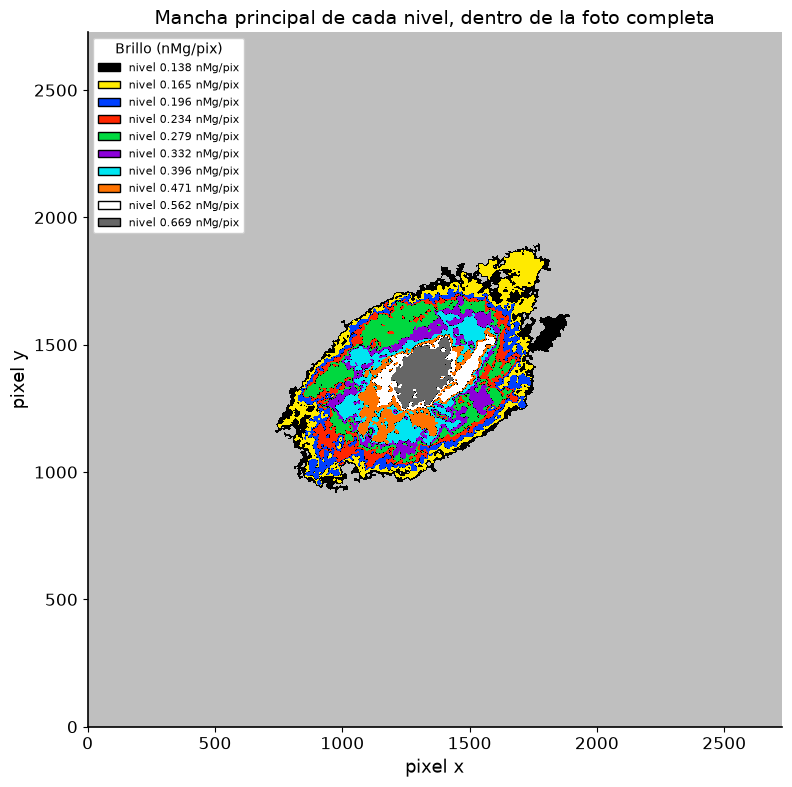

In [27]:
suave = gaussian_filter(limpia, 3)
referencia = suave[suave > 8 * sigma]
niveles = np.geomspace(np.percentile(referencia, 5), np.percentile(referencia, 90), 10)

manchas = []
for nivel in niveles:
    regiones, n = label(suave > nivel)
    if n == 0:
        continue
    conteo = np.bincount(regiones.ravel())
    conteo[0] = 0
    cual = int(np.argmax(conteo))
    if conteo[cual] == 0:
        continue
    manchas.append((int(conteo[cual]), float(nivel), regiones == cual))

# Primero la mancha grande (corte bajo). La chica queda encima.
manchas.sort(key=lambda m: m[0], reverse=True)

# Colores alternados, cambiando el negro del centro por uno diferente (ejemplo: gris claro).
colores = np.array([
    [0.00, 0.00, 0.00],   # negro, primer nivel (más externo)
    [1.00, 0.92, 0.00],
    [0.00, 0.25, 1.00],
    [1.00, 0.15, 0.00],
    [0.00, 0.85, 0.25],
    [0.55, 0.00, 0.85],
    [0.00, 0.90, 0.95],
    [1.00, 0.45, 0.00],
    [1.00, 1.00, 1.00],
    [0.40, 0.40, 0.40],  # gris medio, reemplazando el negro del centro
])

alto, ancho = limpia.shape
lienzo = np.full((alto, ancho, 3), 0.75)
bordes = np.zeros((alto, ancho), dtype=bool)
for i, (_, nivel, mascara) in enumerate(manchas):
    # Si es el último nivel (más interno), usa el nuevo color distinto.
    if i == len(manchas) - 1 and len(manchas) <= len(colores):
        lienzo[mascara] = colores[-1]
    else:
        lienzo[mascara] = colores[i % (len(colores)-1)]
    # Borde = mancha menos su interior.
    bordes |= mascara & ~binary_erosion(mascara)
lienzo[bordes] = 0.0

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(lienzo, origin="lower", extent=[0, ancho, 0, alto], interpolation="nearest")
ax.set_xlim(0, ancho)
ax.set_ylim(0, alto)
ax.set_aspect("equal")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
ax.set_title("Mancha principal de cada nivel, dentro de la foto completa")
for lado in ax.spines.values():
    lado.set_color("black")
    lado.set_linewidth(1.2)

leyenda = []
for i, (_, nivel, _) in enumerate(manchas):
    if i == len(manchas) - 1 and len(manchas) <= len(colores):
        color_leg = colores[-1]
    else:
        color_leg = colores[i % (len(colores)-1)]
    leyenda.append(Patch(
        facecolor=color_leg, edgecolor="black",
        label=f"nivel {nivel:.3f} nMg/pix"
    ))
ax.legend(handles=leyenda, loc="upper left", framealpha=1, fontsize=8, title="Brillo (nMg/pix)")
fig.tight_layout()
plt.show()


##### Ahora veamos las elipses que se ajustan a esas manchas

In [28]:
def elipse(mascara):
    """
    Calcula el centro, los semiejes, el cociente b/a y el ángulo de una elipse ajustada a la 'mascara'.
    """
    ys, xs = np.nonzero(mascara)
    if xs.size < 200:
        return None
    xc, yc = xs.mean(), ys.mean() # Este es el centro de todos los puntos de la mancha
    dx, dy = xs - xc, ys - yc
    matriz = [
        [np.mean(dx * dx), np.mean(dx * dy)],
        [np.mean(dx * dy), np.mean(dy * dy)]
    ]
    valores, vectores = np.linalg.eigh(matriz)
    orden = np.argsort(valores)[::-1] # Ordena los valores de mayor a menor
    valores = valores[orden]
    vectores = vectores[:, orden]
    semimayor = 2 * np.sqrt(valores[0])
    semimenor = 2 * np.sqrt(valores[1])
    angulo = np.degrees(np.arctan2(vectores[1, 0], vectores[0, 0])) % 180
    # xc, yc = centro; semimayor, semimenor = longitudes de ejes; semimenor/semimayor = b/a; angulo = orientación
    return xc, yc, semimayor, semimenor, semimenor / semimayor, angulo

def isofotas(limpia, sigma):
    """
    Calcula diversas isofotas usando varios niveles de brillo, ajustando una elipse a cada una.
    El centro y b/a se calculan a partir de las dos más grandes (dominadas por el disco).
    Retorna una lista de elipses (filas) y los parámetros medios del disco.
    """
    suave = gaussian_filter(limpia, 3)
    referencia = suave[suave > 8 * sigma]
    niveles = np.geomspace(
        np.percentile(referencia, 5),
        np.percentile(referencia, 90),
        10
    )
    filas = []
    for nivel in niveles:
        regiones, n = label(suave > nivel)
        if n == 0:
            continue
        conteo = np.bincount(regiones.ravel())
        conteo[0] = 0  # Ignorar fondo
        idx_max = np.argmax(conteo)
        forma = elipse(regiones == idx_max)
        if forma is not None and 200 < forma[2] < 1100: # 200 macha muy chica, 1100 mancha fuera
            filas.append(forma)
    # Ordena las elipses por tamaño del semieje mayor, de mayor a menor
    filas.sort(key=lambda f: f[2], reverse=True)
    externas = filas[:2]  # Tomar las dos elipses más grandes para hacer los calculos
    centro_x = float(np.median([f[0] for f in externas]))
    centro_y = float(np.median([f[1] for f in externas]))
    razon = float(np.median([f[4] for f in externas]))
    angulo = float(np.median([f[5] for f in externas]))
    return filas, centro_x, centro_y, razon, angulo

filas, cx, cy, razon, angulo = isofotas(limpia, sigma)

##### El centro a partir de las dos elipses de afuera

Ya con las isofotas calculados tomamos las dos más grandes  porque son las que pertenecen al disco y también hablan de que tan inclinado esta el disco respecto a nuestro punto de vista con su achatamiento precisamente. y de ahi el centro promedio de esas dos es precisamente el que vamos a deteerminar como el centro de la galaxia.

Además usando la variable dentro del .fits que me diece en la dirección que estan la galaxia para un pixel especifico y cuantos segundo de arco cubre cada pixel podemos saber las coordenadas ecuatoriales Ascención recta y declinación del centro de la Galaxia.


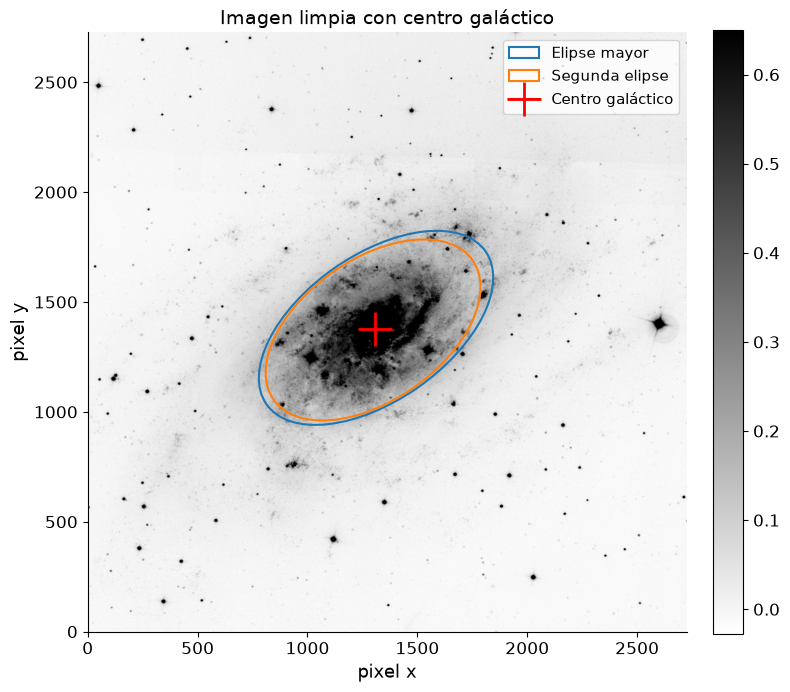


===== Centro de NGC 2403 =====
Centro (pixel):    (1305, 1377)
Centro (RA, Dec):  (114.206°, 65.601°)



In [29]:
# Calcular las coordenadas del centro en el cielo (no se altera)
ra = cabecera["CRVAL1"] + cabecera["CD1_1"] * (cx - cabecera["CRPIX1"])
dec = cabecera["CRVAL2"] + cabecera["CD2_2"] * (cy - cabecera["CRPIX2"])

# Mostrar la imagen limpia con las dos elipses de afuera y el centro
fig, ax = plt.subplots(figsize=(8, 8))
vmin_limpia, vmax_limpia = np.percentile(limpia, [1, 99])
im = ax.imshow(limpia, origin="lower", cmap="gray_r", vmin=vmin_limpia, vmax=vmax_limpia)
ax.set_title("Imagen limpia con centro galáctico")
for i, forma in enumerate(filas[:2]):
    ax.add_patch(Ellipse(
        (forma[0], forma[1]),
        2 * forma[2],
        2 * forma[3],
        angle=forma[5],
        fill=False,
        edgecolor="C0" if i == 0 else "C1",
        linewidth=1.5,
        label="Elipse mayor" if i == 0 else "Segunda elipse",
    ))
ax.plot(cx, cy, marker="+", color="red", markersize=25, markeredgewidth=2, label="Centro galáctico")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
ax.legend()
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

print("\n===== Centro de NGC 2403 =====")
print(f"Centro (pixel):    ({cx:.0f}, {cy:.0f})")
print(f"Centro (RA, Dec):  ({ra:.3f}°, {dec:.3f}°)")
print("============================\n")

#### Inclinación

$q = b/a$ es el achatamiento promedio de las dos elipses de afuera. Un disco circular, visto de lado, se ve elíptico. $q_0 = 0.2$ es el grosor mínimo, de canto.

$$
\cos^2 i = \frac{q^2 - q_0^2}{1 - q_0^2}
$$

$q = 1$ da $i = 0^\circ$ (de frente). $q = q_0$ da $i = 90^\circ$ (de canto).

**Fórmula de Hubble (1926, *ApJ*, 64, 321)**. $q_0 = 0.2$ es el grosor de canto medido por Holmberg **(1946, *Medd. Lunds Astron. Obs.* Ser. II, N.º 117)**.


In [30]:
# cos^2 i = (q^2 - q0^2) / (1 - q0^2).
coseno2 = np.clip((razon**2 - Q0**2) / (1 - Q0**2), 0, 1)
inc = float(np.degrees(np.arccos(np.sqrt(coseno2))))

print("\n===== Inclinación de NGC 2403 =====")
print(f"b/a:          {razon:.3f}")
print(f"Inclinación:  {inc:.0f}°")
print("===============================\n")



===== Inclinación de NGC 2403 =====
b/a:          0.563
Inclinación:  58°



#### Distribución de brillo superficial, Regiones del bulbo y del disco 

##### Radio en el disco de frente

El disco es un círculo. Inclinado se ve como una elipse: el eje mayor conserva su tamaño y el menor queda comprimido.

A cada píxel se le escribe la distancia al centro que tendría si el disco se viera de frente. Para eso se giran las coordenadas hasta el eje de la elipse y se estira el eje menor dividiéndolo por $q = b/a$.

Los píxeles de una misma elipse quedan con el mismo número: el semieje mayor, en píxeles. El perfil promedia el brillo en esos anillos.


In [31]:
def radio_eliptico(forma, cx, cy, razon, angulo):
    """Distancia de cada pixel al centro de la galaxia. Como si la galaxia estuviera de frente"""
    # Corriendo las coordenadas en relación al centro de la galaxia
    yy, xx = np.indices(forma)
    dx, dy = xx - cx, yy - cy
    #  Dirección del semieje mayor
    ca, sa = np.cos(np.deg2rad(angulo)), np.sin(np.deg2rad(angulo))
    mayor = dx * ca + dy * sa
    menor = -dx * sa + dy * ca
    return np.sqrt(mayor**2 + (menor / razon) ** 2)

radio = radio_eliptico(limpia.shape, cx, cy, razon, angulo)

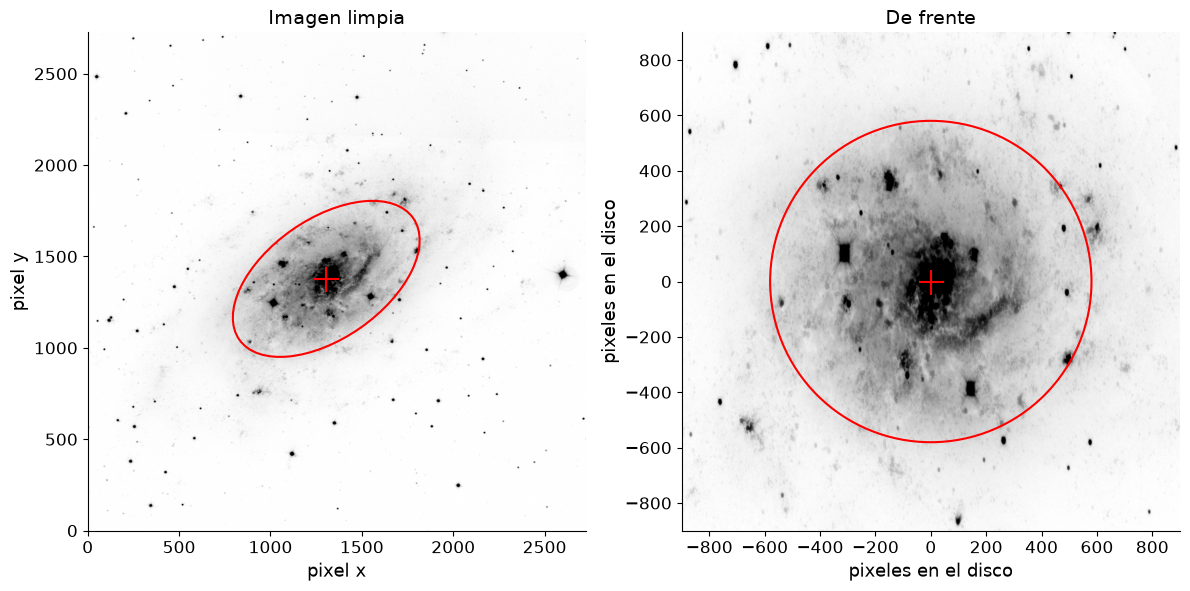

In [32]:
# Estira el eje menor por 1/q. En ese plano el disco se ve redondo.
ca, sa = np.cos(np.deg2rad(angulo)), np.sin(np.deg2rad(angulo))
lado = 1800
eje = np.linspace(-lado / 2, lado / 2, lado)
X, Y = np.meshgrid(eje, eje)
mayor, menor = X, Y * razon
x = cx + mayor * ca - menor * sa
y = cy + mayor * sa + menor * ca
frente = map_coordinates(limpia, [y, x], order=1, cval=np.nan)

a_promedio = float(np.median([f[2] for f in filas[:2]]))
vmin, vmax = np.nanpercentile(frente, [1, 99])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(limpia, origin="lower", cmap="gray_r", vmin=vmin, vmax=vmax)
axes[0].add_patch(Ellipse(
    (cx, cy), 2 * a_promedio, 2 * a_promedio * razon,
    angle=angulo, fill=False, edgecolor="red", linewidth=1.5,
))
axes[0].plot(cx, cy, marker="+", color="red", markersize=18, markeredgewidth=1.5)
axes[0].set_title("Imagen limpia")
axes[0].set_xlabel("pixel x")
axes[0].set_ylabel("pixel y")

axes[1].imshow(
    frente, origin="lower", cmap="gray_r", vmin=vmin, vmax=vmax,
    extent=[-lado / 2, lado / 2, -lado / 2, lado / 2],
)
axes[1].add_patch(Circle((0, 0), a_promedio, fill=False, edgecolor="red", linewidth=1.5))
axes[1].plot(0, 0, marker="+", color="red", markersize=18, markeredgewidth=1.5)
axes[1].set_aspect("equal")
axes[1].set_title("De frente")
axes[1].set_xlabel("pixeles en el disco")
axes[1].set_ylabel("pixeles en el disco")
fig.tight_layout()
plt.show()

##### Perfil de brillo

Cada píxel ya tiene la distancia al centro en el disco de frente. El perfil junta esos pixeles en anillos de 15 px y promedia su brillo. Ese promedio, $F$, está en nanomaggies por pixel.

La escala es el tamaño de un píxel en el cielo, unos 0.4 segundos de arco. El brillo de un pedazo de $1''\times 1''$ es $F/\mathrm{escala}^2$. En magnitudes AB:

$$
\mu = 22.5 - 2.5\log_{10}\left(\frac{F}{\mathrm{escala}^2}\right)
$$

El 22.5 es el cero AB de un nanomaggie (Oke y Gunn, 1983). $I(R)$ y $\mu(R)$ son el mismo perfil: $I$ es el flujo y $\mu$ es ese flujo en mag/arcsec². Más luz da un $I$ grande y un $\mu$ chico. El perfil se corta cuando el anillo ya no pasa de $2\sigma$.

##### Disco y bulbo

 Entre 440 y 640 px el perfil de esta galaxia ya es recto. Adentro el bulbo lo levanta. Afuera el disco se trunca y cae más rápido. 

**Carroll y Ostlie (2007), ecuación 25.3**, escriben el disco como

$$
\mu(R) = \mu_0 + 1.086\,\frac{R}{h}, \qquad 1.086 = \frac{2.5}{\ln 10}.
$$

La pendiente de $\mu$ contra $R$ es $1.086/h$, así que $h$ sale de dividir 1.086 por esa pendiente **(Carroll y Ostlie, 2007, ec. 25.3).**

$\mu_0$ es el corte de esa recta en $R = 0$. $I_0$ es el mismo número vuelto a nanomaggies por pixel. Es el brillo del disco extrapolado al centro, no el brillo medido ahí: en el centro hay disco más bulbo.

La luz del disco, de $R = 0$ a infinito, es

$$
\int_0^{\infty} I_0 e^{-R/h}\,2\pi R\,dR = 2\pi I_0 h^2.
$$

El bulbo es el exceso de la medida sobre el disco extrapolado. Ese exceso está en nanomaggies por pixel. 

La zona de intersección es el último anillo en el que el exceso sigue siendo positivo. De ahí hacia afuera manda el disco. El disco no termina en ese radio: sigue, y deja de ser exponencial pasada la ventana de 640 px.

$$
B/T = \frac{L_\text{bulbo}}{L_\text{bulbo} + 2\pi I_0 h^2}
$$


In [33]:
def perfil(limpia, radio, sigma, escala):
    """Brillo medio en anillos elipticos, en mag/arcsec^2."""
    radios, flujos = [], []
    for r1 in range(10, 1000, 15):
        # Pixeles que caen entre r1 y r1 + 15
        anillo = (radio >= r1) & (radio < r1 + 15)
        # Si hay menos de 40 pixeles en el anillo, se salta
        if anillo.sum() < 40:
            continue
        flujo = limpia[anillo].mean()
        if flujo <= 2 * sigma:
            break
        radios.append(r1 + 7.5) # Radio medio del anillo
        flujos.append(flujo) # Flujo medio del anillo
    radios, flujos = np.array(radios), np.array(flujos)
    # Magnitud por segundo de arco al cuadrado del anillo
    mu = CERO_AB - 2.5 * np.log10(flujos / escala**2)
    return radios, flujos, mu

def disco_y_bulbo(radios, flujos, mu, escala, r_min=440, r_max=640):
    """
    Recta de mu contra R entre r_min y r_max px: ahi el disco es exponencial
    y todavia no se trunca. El bulbo es lo que queda por encima, en el centro.
    """
    zona = (radios > r_min) & (radios < r_max)
    pendiente, mu0 = np.polyfit(radios[zona], mu[zona], 1)
    h = FACTOR_MAG / pendiente
    i0 = escala**2 * 10 ** ((CERO_AB - mu0) / 2.5) # brillo del disco en el centro
    disco = i0 * np.exp(-radios / h)
    exceso = flujos - disco

    cruce = 0.0
    for r, extra in zip(radios, exceso):
        if extra > 0:
            cruce = float(r)
        else:
            break
    # 15 px es el ancho de los anillos
    dr = float(np.median(np.diff(radios))) 
    # Radio de los anillos que caen dentro del bulbo
    dentro = radios <= cruce
    # Luz del bulbo (el exceso de la medida sobre la curva)
    luz_bulbo = np.sum(np.clip(exceso[dentro], 0, None) * 2 * np.pi * radios[dentro] * dr)
    # Luz del disco
    luz_disco = 2 * np.pi * i0 * h**2
    return {
        "h": float(h),
        "mu0": float(mu0),
        "i0": float(i0),
        "disco": disco,
        "cruce": cruce,
        "bt": float(luz_bulbo / (luz_bulbo + luz_disco)),
        "flujo": float((luz_bulbo + luz_disco)),
    }

radios, flujos, mu = perfil(limpia, radio, sigma, escala)
ajuste = disco_y_bulbo(radios, flujos, mu, escala)

print("\n===== Relación bulbo/total de NGC 2403 =====")
print(f"Bulbo / total (B/T):  {ajuste['bt']:.3f}")
print("========================================\n")


===== Relación bulbo/total de NGC 2403 =====
Bulbo / total (B/T):  0.005



La relación entre la luz del bulbo y la luz total de la galaxia en este caso para NGC 2403 es de **0.005** según la tabla 25.1 de Carroll y Ostlie (2007) (Descrita más adelnate en este notebook)  esto corresponde a una galaxia de tipo **Sc**, aunque aún podemos hacer una verificación más a través de pith angle

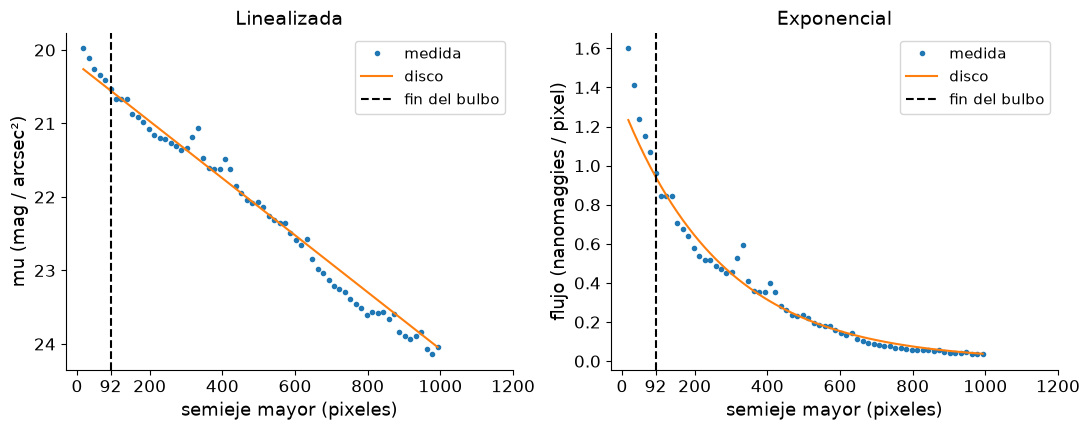

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

axes[0].plot(radios, mu, "o", ms=3, label="medida")
axes[0].plot(radios, ajuste["mu0"] + FACTOR_MAG * radios / ajuste["h"], label="disco")
axes[0].axvline(ajuste["cruce"], color="k", ls="--", label="fin del bulbo")
axes[0].invert_yaxis()
axes[0].set_xlabel("semieje mayor (pixeles)")
axes[0].set_ylabel("mu (mag / arcsec²)")
axes[0].set_title("Linealizada")
axes[0].legend()

axes[1].plot(radios, flujos, "o", ms=3, label="medida")
axes[1].plot(radios, ajuste["disco"], label="disco")
axes[1].axvline(ajuste["cruce"], color="k", ls="--", label="fin del bulbo")
axes[1].set_xlabel("semieje mayor (pixeles)")
axes[1].set_ylabel("flujo (nanomaggies / pixel)")
axes[1].set_title("Exponencial")
axes[1].legend()

for ax in axes:
    marcas = [t for t in ax.get_xticks() if t >= radios.min() - 20]
    marcas.append(ajuste["cruce"])
    ax.set_xticks(sorted(marcas))
    ax.set_xticklabels([f"{t:.0f}" for t in sorted(marcas)])

fig.tight_layout()
plt.show()

A la derecha está la luz del anillo, en nanomaggies por pixel. El disco cae como una exponencial: $I(R) = I_0 e^{-R/h}$.
A la izquierda esa misma curva está en magnitudes. El logaritmo de una exponencial es una recta, así que $\mu(R) = \mu_0 + 1.086\,R/h$. La pendiente de esa recta es la escala del disco. El bulbo es el exceso de brillo del centro sobre la curva que representa la estimación de cual debería de ser el brillo del disco en esas regiones centrale si no hubiera bulbo


#### Brazos y ángulo de paso

En el disco de frente los brazos se ven como espirales. Carroll y Ostlie (2007) definen el ángulo de paso $\psi$ como el ángulo entre la tangente al brazo y el círculo de radio constante. Un $\psi$ pequeño deja los brazos muy enrollados; uno grande los abre.

En una espiral logarítmica

$$
\phi = \cot\psi\,\ln R + \mathrm{constante}.
$$

$R$ es la distancia al centro y $\phi$ es el ángulo del rayo que sale del centro y pasa por el píxel, medido desde el eje mayor. $\cot\psi = 1/\tan\psi$ dice cuánto gira el brazo cuando $R$ crece. La constante solo fija dónde empieza el brazo.

La imagen se deproyecta con el mismo giro y el mismo $q$ del radio elíptico. El disco se parte en 30 anillos de $\ln R$, entre 120 y 620 px, y en 60 sectores de $\phi$. A cada anillo se le resta su mediana: el disco liso es parejo alrededor del círculo y desaparece. Quedan los brazos, más brillantes que el hueco que hay entre ellos.

El brazo no se queda en el mismo $\phi$. Al pasar de un anillo al siguiente gira un poco, y cuánto gira lo fija $\psi$. Se prueba un valor, por ejemplo $20^\circ$, y se calcula cuánto debería haberse corrido cada anillo respecto del anillo del medio. Ese corrimiento se deshace: los anillos de afuera se giran hacia atrás, los de adentro hacia el otro lado y el del medio se deja quieto. Los 30 anillos se suman en una sola vuelta de $\phi$.

Si ese $\psi$ es el del brazo, su luz queda en las mismas columnas y la suma tiene un pico alto. Si es otro, cada anillo deja el brazo en una columna distinta y la suma queda plana. El puntaje es ese pico menos el nivel típico de la suma. Se repite desde $8^\circ$ hasta $45^\circ$, y el ángulo con el puntaje más alto es el ángulo de paso.


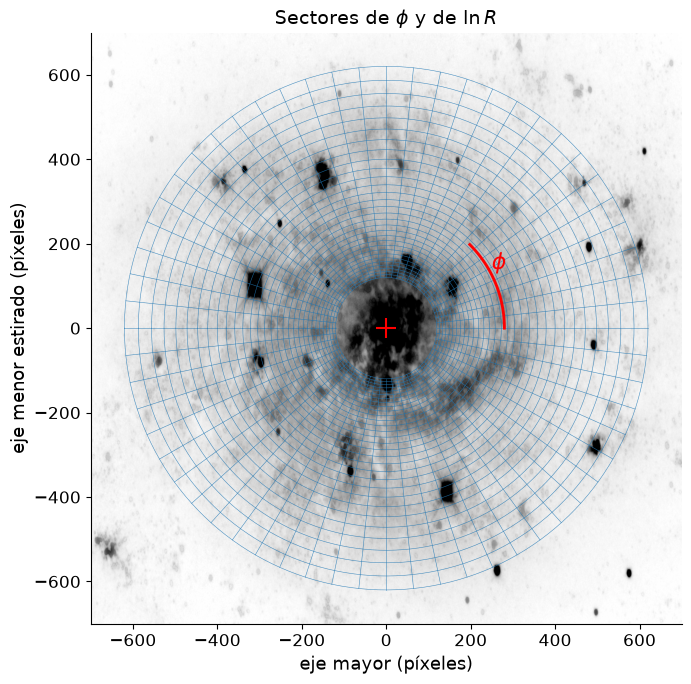

In [35]:
# φ es la dirección del rayo que sale del centro, medida desde el eje mayor.
lado = 1400
eje = np.linspace(-lado / 2, lado / 2, lado)
X, Y = np.meshgrid(eje, eje)
ca, sa = np.cos(np.deg2rad(angulo)), np.sin(np.deg2rad(angulo))
mayor, menor = X, Y * razon
x = cx + mayor * ca - menor * sa
y = cy + mayor * sa + menor * ca
frente = map_coordinates(limpia, [y, x], order=1, cval=np.nan)
vmin, vmax = np.nanpercentile(frente, [1, 99])

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(
    frente, origin="lower", cmap="gray_r", vmin=vmin, vmax=vmax,
    extent=[-lado / 2, lado / 2, -lado / 2, lado / 2],
)

# 30 anillos en ln R y 60 sectores de phi, entre 120 y 620 px.
ln_bordes = np.linspace(np.log(120), np.log(620), 31)
phi_bordes = np.linspace(-np.pi, np.pi, 61)
vuelta = np.linspace(-np.pi, np.pi, 360)
for radio in np.exp(ln_bordes):
    ax.plot(radio * np.cos(vuelta), radio * np.sin(vuelta), color="C0", lw=0.4, alpha=0.8)
for ph in phi_bordes[:-1]:
    ax.plot(
        [120 * np.cos(ph), 620 * np.cos(ph)],
        [120 * np.sin(ph), 620 * np.sin(ph)],
        color="C0", lw=0.4, alpha=0.8,
    )

arco = np.linspace(0, np.deg2rad(45), 40)
ax.plot(280 * np.cos(arco), 280 * np.sin(arco), color="red", lw=2)
ax.text(250, 140, r"$\phi$", color="red", fontsize=16)
ax.plot(0, 0, "+", color="red", ms=14, mew=1.5)
ax.set_xlim(-lado / 2, lado / 2)
ax.set_ylim(-lado / 2, lado / 2)
ax.set_aspect("equal")
ax.set_title(r"Sectores de $\phi$ y de $\ln R$")
ax.set_xlabel("eje mayor (píxeles)")
ax.set_ylabel("eje menor estirado (píxeles)")
fig.tight_layout()
plt.show()


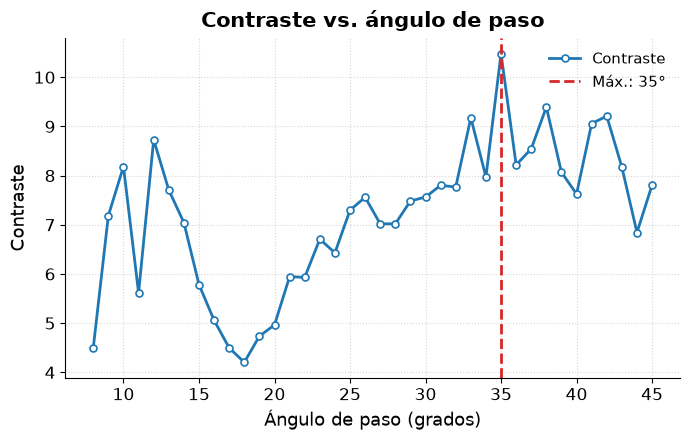


===== Resultados de clasificación de NGC 2403 =====
Relación bulbo/total (B/T):    0.005
Ángulo de paso de los brazos:  35°
Tipo morfológico según Hubble: Scd



In [36]:
def angulo_de_paso(limpia, cx, cy, razon, angulo):
    """
    Espiral logaritmica: phi = cot(psi) ln(R) + constante.
    Se deproyecta el disco y se prueba cual psi alinea los brazos.
    """
    suave = gaussian_filter(limpia, 4)[::2, ::2] # solo 1 de cada 2 pixeles contiene información relevante para el algoritmo
    yy, xx = np.indices(suave.shape) * 2 # El 2 es por la linea de arriba que se quedo con solo uno de cada dos pixeles
    dx, dy = xx - cx, yy - cy
    ca, sa = np.cos(np.deg2rad(angulo)), np.sin(np.deg2rad(angulo))
    mayor = dx * ca + dy * sa
    menor = (-dx * sa + dy * ca) / razon
    radio = np.sqrt(mayor**2 + menor**2)
    phi = np.arctan2(menor, mayor)

    # Traduciendo de pixeles a coordenadas phi y radio
    dentro = (radio > 120) & (radio < 620) # Solo queda el disco sin bulbo ni exterior
    ln_r, ph, valor = np.log(radio[dentro]), phi[dentro], np.clip(suave[dentro], 0, None)
    n_r, n_phi = 30, 60
    ln_b = np.linspace(ln_r.min(), ln_r.max(), n_r + 1)
    phi_b = np.linspace(-np.pi, np.pi, n_phi + 1)
    mapa = np.zeros((n_r, n_phi))
    cuenta = np.zeros((n_r, n_phi))
    # Veamos donde cae cada pixel en este mapa de phi y r 
    ir = np.clip(np.digitize(ln_r, ln_b) - 1, 0, n_r - 1)
    ip = np.clip(np.digitize(ph, phi_b) - 1, 0, n_phi - 1)
    # Suma el valor de cada pixel en el mapa, y cuenta cuántos pixeles hay en cada posición
    np.add.at(mapa, (ir, ip), valor)
    np.add.at(cuenta, (ir, ip), 1)
    cuenta[cuenta == 0] = 1
    residuo = mapa / cuenta # Brillo medio de cada casilla
    # Quita el brillo medio de cada anillo (material que no perteneces al brazo expiral)
    residuo -= np.median(residuo, axis=1, keepdims=True)
    ln_c = 0.5 * (ln_b[:-1] + ln_b[1:])
    dphi = phi_b[1] - phi_b[0]

    def contraste(psi):
        cot = 1 / np.tan(np.deg2rad(psi))
        perfil = np.zeros(n_phi)
        for i, ln in enumerate(ln_c):
            perfil += np.roll(residuo[i], -int(round(cot * (ln - ln_c[n_r // 2]) / dphi)))
        return perfil.max() - np.median(perfil)

    candidatos = np.arange(8, 46)
    puntajes = np.array([contraste(p) for p in candidatos])
    return float(candidatos[np.argmax(puntajes)]), candidatos, puntajes

def clasificar(bt, paso):
    """Tabla 25.1. Mas abierto y con menos bulbo que una Sc: Scd."""
    if bt < 0.05 and paso > 18:
        return "Scd"
    if bt < 0.13 and paso > 12:
        return "Sc"
    if bt < 0.30 and paso > 6:
        return "Sb"
    return "Sa"

paso, angulos, puntajes = angulo_de_paso(limpia, cx, cy, razon, angulo)

tipo = clasificar(ajuste["bt"], paso)

# Gráfica más profesional pero simple
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=100)
ax.plot(
    angulos, puntajes,
    color='#1f77b4',
    linewidth=2,
    marker='o',
    markersize=5,
    markerfacecolor='white',
    markeredgewidth=1.2,
    markeredgecolor='#1f77b4',
    label="Contraste"
)
ax.axvline(paso, color="#d62728", lw=2, ls="--", label=f"Máx.: {paso:.0f}°")
ax.set_xlabel("Ángulo de paso (grados)", fontsize=13)
ax.set_ylabel("Contraste", fontsize=13)
ax.set_title("Contraste vs. ángulo de paso", fontsize=15, weight='bold', pad=8)
ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.5)
ax.legend(fontsize=11, loc="best", frameon=False)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
fig.tight_layout()
plt.show()

print("\n===== Resultados de clasificación de NGC 2403 =====")
print(f"Relación bulbo/total (B/T):    {ajuste['bt']:.3f}")
print(f"Ángulo de paso de los brazos:  {paso:.0f}°")
print(f"Tipo morfológico según Hubble: {tipo}")
print("================================================\n")


#### Clasificación de Hubble

Carroll y Ostlie (2007), tabla 25.1, da el tipo por la luz del bulbo y por lo apretados que van los brazos:

| Tipo | $B/T$ | Ángulo de paso |
| --- | --- | --- |
| Sa | 0.30 | $\sim 6^\circ$ |
| Sb | 0.13 | $\sim 12^\circ$ |
| Sc | 0.05 | $\sim 18^\circ$ |

$B/T$ es $L_\mathrm{bulbo}/L_\mathrm{total}$, Entonces lo que obtuvimos como resultado para NGC 2403 es un  B/T = 0.005  y un Pitch Angle de 35°. Ambas medidas se alejan de Sc en dirección a una galaxia de tipo Sd. Así que, **la galaxia NGC 2403 es de tipo Scd**


#### Distancia y escala del disco

La curva que se provee ya está deproyectada: $V$ es la velocidad en el disco, no $V\sin i$. $V_\mathrm{max}$ es la mediana de los últimos 40 puntos, la parte plana.

Carroll y Ostlie (2007), ecuación 25.7, es la relación de Tully–Fisher para una Sc. Una espiral más luminosa gira más rápido, así que $V_\mathrm{max}$ fija la magnitud absoluta:

$$
M_B = -11.0\log_{10} V_\mathrm{max} + 3.31.
$$

La magnitud aparente sale de la luz total, bulbo más disco, en nanomaggies. Esa integral se hizo como si el disco se viera de frente. En la foto el área está comprimida por $q = b/a$, así que el flujo de la imagen es esa luz por $q$:

$$
m_g = 22.5 - 2.5\log_{10}(F_\mathrm{total}\, q).
$$

La extinción interna se estima con $A = 1.5\log_{10}(1/q)$. Esa $A$ es polvo de la propia galaxia. El polvo de la Vía Láctea, entre ella y nosotros, no se resta: NGC 2403 está en una región despejada, lejos del plano. Tampoco se usa el redshift. Es una galaxia cercana. El módulo de distancia mezcla $m_g$ con $M_B$, porque no hay fotometría en B, igual son bandas vecinas entonces no hay mucha diferencia.

$$
D = 10^{((m_g - A) - M_B + 5)/5}\ \mathrm{pc}.
$$

Un segundo de arco a esa distancia mide $D_\mathrm{Mpc}/206.265$ kpc. La escala del disco es $h$ en píxeles, pasada a segundos de arco y luego a kpc con ese factor. El radio de intersección se pasa a kpc del mismo modo.


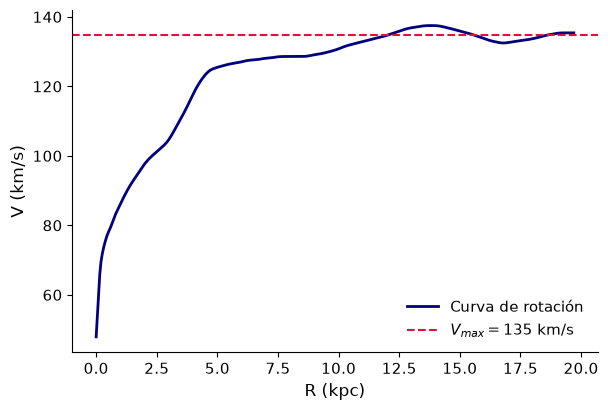


===== Distancia y escala del disco =====
Vmax:                      135 km/s
m_g:                       8.59
Extinción A:               0.37
M_B:                       -20.12
Distancia:                 4.7 Mpc
Escala del disco:          280 px = 111 arcsec = 2.5 kpc
Intersección bulbo-disco:  92 px = 0.83 kpc



In [37]:
# Flujo integrado como disco de frente. En el cielo el área lleva q = b/a.
magnitud = CERO_AB - 2.5 * np.log10(ajuste["flujo"] * razon)
vmax = float(np.median(curva_v[-40:]))
# M(B) = -11.0 + 3.31\log_{10} V.
mb = TF_SC[0] * np.log10(vmax) + TF_SC[1]
extincion = GAMMA * np.log10(1 / razon)
modulo = (magnitud - extincion) - mb
distancia = 10 ** ((modulo + 5) / 5) / 1e6

arco_a_kpc = distancia / 206.265
h_kpc = ajuste["h"] * escala * arco_a_kpc
cruce_kpc = ajuste["cruce"] * escala * arco_a_kpc

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(curva_r, curva_v, color="navy", linewidth=2, label="Curva de rotación")
ax.axhline(vmax, color="crimson", ls="--", linewidth=1.5, label=f"$V_{{max}} = {vmax:.0f}$ km/s")
ax.set_xlabel("R (kpc)", fontsize=12)
ax.set_ylabel("V (km/s)", fontsize=12)
ax.tick_params(axis='both', labelsize=11)
ax.legend(frameon=False, fontsize=11, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
plt.show()

print("\n===== Distancia y escala del disco =====")
print(f"Vmax:                      {vmax:.0f} km/s")
print(f"m_g:                       {magnitud:.2f}")
print(f"Extinción A:               {extincion:.2f}")
print(f"M_B:                       {mb:.2f}")
print(f"Distancia:                 {distancia:.1f} Mpc")
print(f"Escala del disco:          {ajuste['h']:.0f} px = {ajuste['h'] * escala:.0f} arcsec = {h_kpc:.1f} kpc")
print(f"Intersección bulbo-disco:  {ajuste['cruce']:.0f} px = {cruce_kpc:.2f} kpc")
print("======================================\n")


La distancia calculada es de 4.7 Mpc un poco por encima del valor de la literatura de 3.2 Mpc. Se mantiene el orden de magnitud lo que hace que sea una buena aproximación.




### Ejercicio 2

Consiga las imágenes de 2 galaxias de disco y 2 galaxias elípticas (todas las imágenes espacialmente bien resueltas). Utilice las imágenes para estimar una clasificación para cada galaxia en el sistema de clasificación de Hubble. Describa en detalle la metodología que usó y la forma como realizó cada medida para realizar su clasificación. ¿Por qué cree que los resultados de su clasificación son robustos?

----


Las imágenes son recortes de la banda g de SDSS **(York et al., 2000)**, descargados del servicio de recortes de los Legacy Surveys **(Dey et al., 2019)**. 

| Galaxia | Clase que se ve | FITS |
| --- | --- | --- |
| NGC 628 | Disco | [imagen](https://www.legacysurvey.org/viewer/cutout.fits?ra=24.173855&dec=15.783643&layer=sdss&pixscale=0.396&bands=g&size=1600) |
| NGC 4254 | Disco | [imagen](https://www.legacysurvey.org/viewer/cutout.fits?ra=184.706771&dec=14.416489&layer=sdss&pixscale=0.396&bands=g&size=1600) |
| NGC 3379 | Elíptica | [imagen](https://www.legacysurvey.org/viewer/cutout.fits?ra=161.956667&dec=12.581631&layer=sdss&pixscale=0.396&bands=g&size=1600) |
| NGC 4374 | Elíptica | [imagen](https://www.legacysurvey.org/viewer/cutout.fits?ra=186.265597&dec=12.886983&layer=sdss&pixscale=0.396&bands=g&size=1600) |


##### Cómo se clasifica

Para clasificar las galaxias se uso el mismo algoritmo que se describe en el primer punto de este notebook para clasificar la galaxia NGC 2403, este funciona igual para las galaxias espirales y tmabién funciona para las galaxias elipticas solo que no se puede calcular ni el pitch angle ni la relación Bulbo y Luminosidad total

Para diferenciar entre elipticas y espirales, se mira un anillo entre la mitad y el 90 % de la elipse grande, partido en 12 sectores de $\phi$. Si el sector más brillante pasa de 1.2 veces la mediana de los sectores, el brillo cambia alrededor del círculo: hay brazos y es un disco. Si el anillo es parejo, no hay brazos y es una elíptica.

Una elíptica se clasifica por lo redonda que se ve:

$$
E_n, \qquad n = 10\,(1 - b/a)
$$

$n = 0$ es un círculo. $n = 7$ es la más aplanada que Hubble admite. Se redondea al entero.

Un disco sí tiene bulbo y brazos. $B/T$ y el ángulo de paso entran en la tabla 25.1 de Carroll y Ostlie (2007), igual que en NGC 2403. La recta del disco se ajusta enn la ventana cerca del 70 % al 105 % de su elipse de afuera.


===== Clasificación de las galaxias =====
NGC628    disco      b/a = 0.80   B/T = 0.009   paso = 22°   tipo = Scd
NGC4254   disco      b/a = 0.73   B/T = 0.016   paso = 20°   tipo = Scd
NGC3379   elíptica   b/a = 0.87   tipo = E1
NGC4374   elíptica   b/a = 0.94   tipo = E1



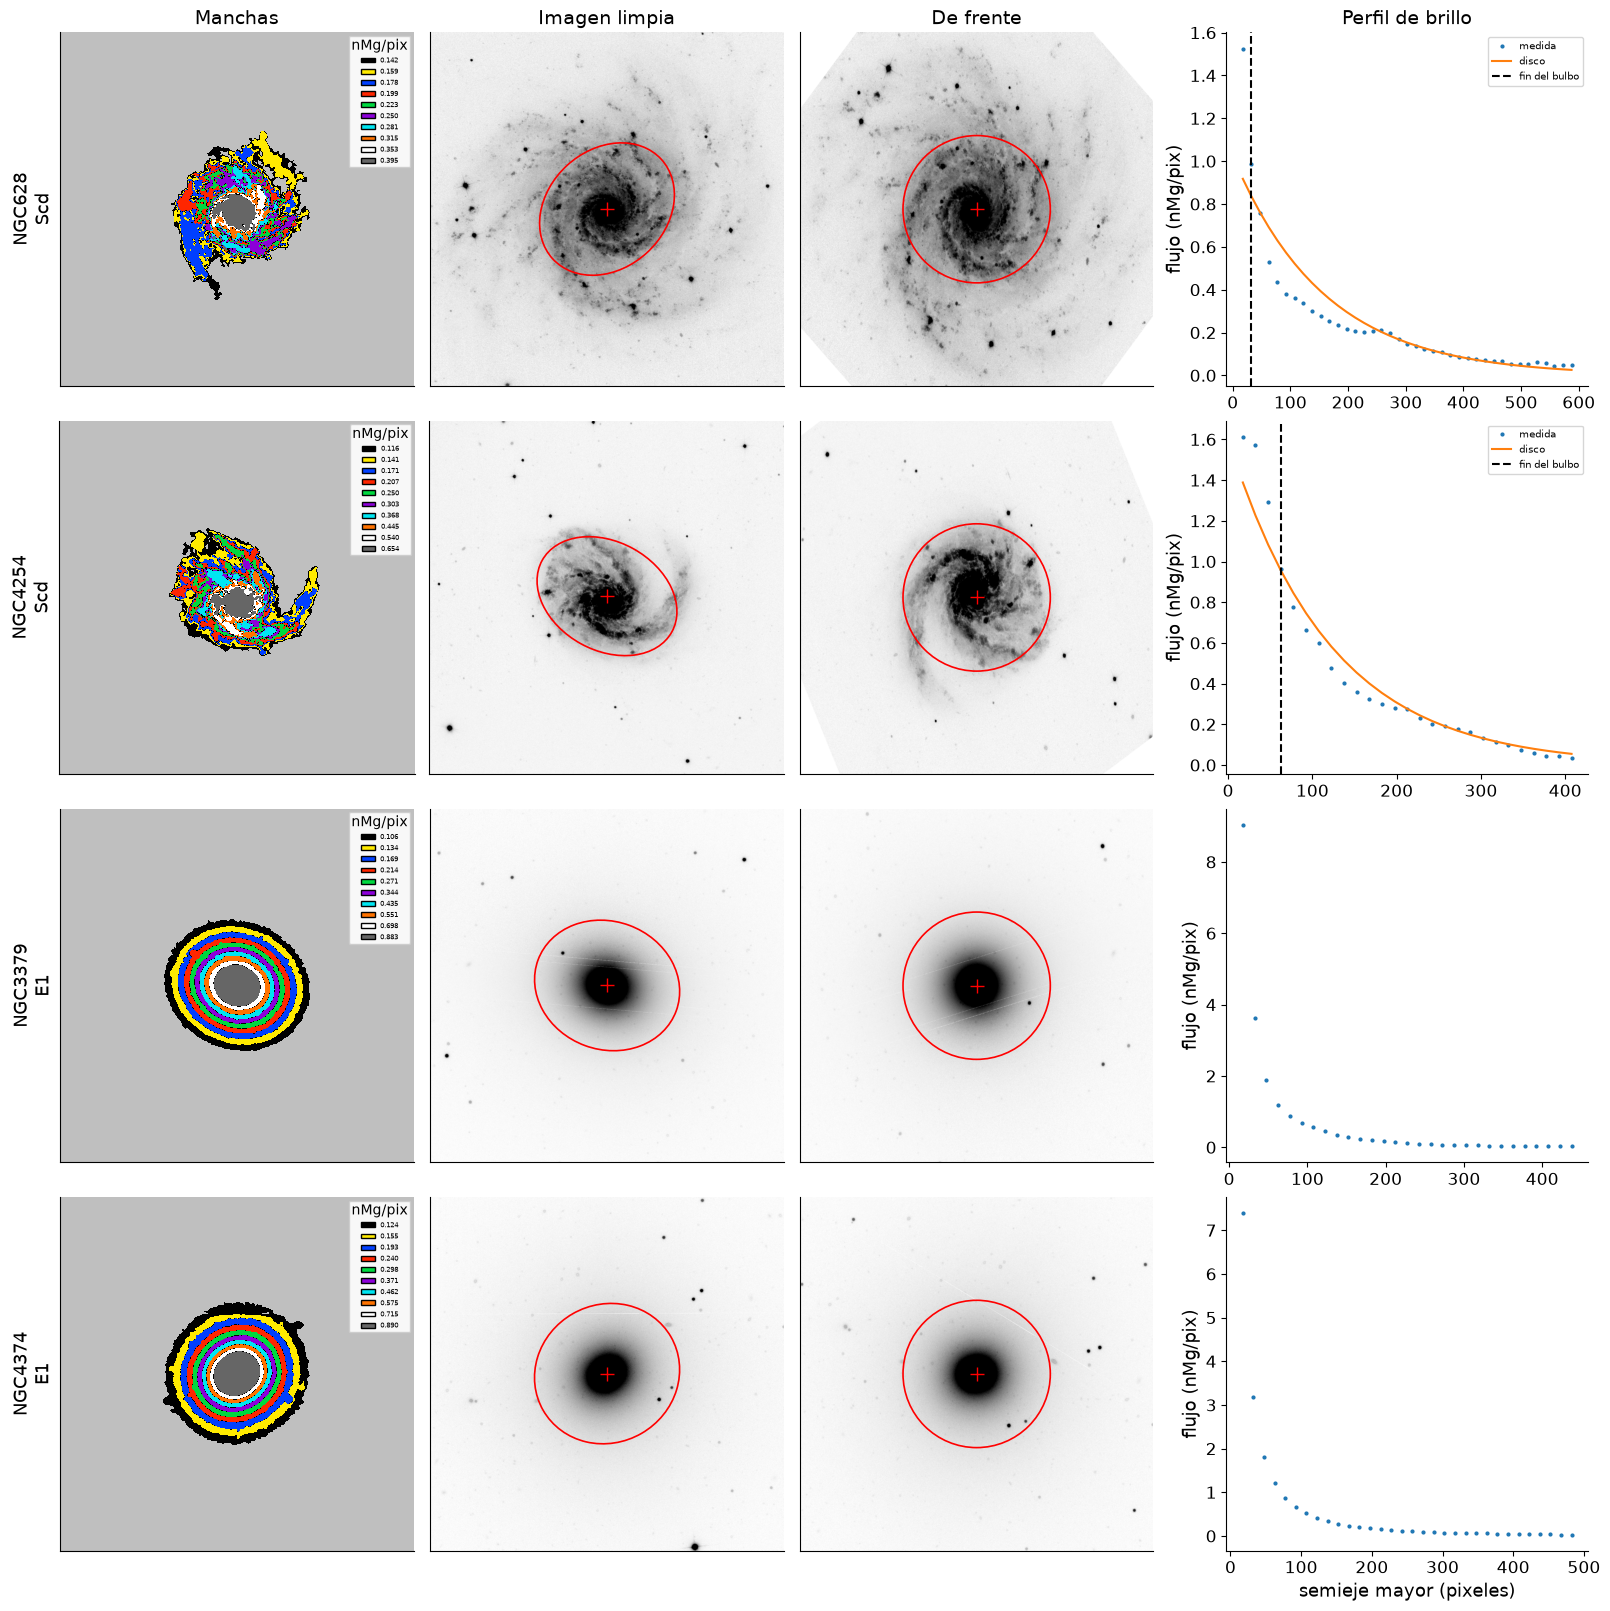

In [38]:
carpeta = CARPETA / "data"
nombres = ["NGC628", "NGC4254", "NGC3379", "NGC4374"]
colores = np.array([
    [0.00, 0.00, 0.00],
    [1.00, 0.92, 0.00],
    [0.00, 0.25, 1.00],
    [1.00, 0.15, 0.00],
    [0.00, 0.85, 0.25],
    [0.55, 0.00, 0.85],
    [0.00, 0.90, 0.95],
    [1.00, 0.45, 0.00],
    [1.00, 1.00, 1.00],
    [0.40, 0.40, 0.40],
])

fig, axes = plt.subplots(len(nombres), 4, figsize=(16, 4 * len(nombres)), constrained_layout=True)
print("\n===== Clasificación de las galaxias =====")
for fila, nombre in enumerate(nombres):
    with fits.open(carpeta / f"{nombre}_g.fits") as hdul:
        imagen = hdul[0].data.astype(float)
        escala = abs(hdul[0].header["CD1_1"]) * 3600.0
    limpia, cielo, sigma = limpiar(imagen)
    filas, cx, cy, razon, angulo = isofotas(limpia, sigma)
    a = filas[0][2]

    # Clasificación entre disco y elíptica
    suave = gaussian_filter(limpia, 4)[::4, ::4]
    yy, xx = np.indices(suave.shape) * 4
    dx, dy = xx - cx, yy - cy
    ca, sa = np.cos(np.deg2rad(angulo)), np.sin(np.deg2rad(angulo))
    mayor = dx * ca + dy * sa
    menor = (-dx * sa + dy * ca) / razon
    radio = np.hypot(mayor, menor)
    phi = np.arctan2(menor, mayor)
    anillo = (radio > 0.5 * a) & (radio < 0.9 * a)
    partes = np.linspace(-np.pi, np.pi, 13)
    brillo = []
    for p0, p1 in zip(partes[:-1], partes[1:]):
        zona = anillo & (phi >= p0) & (phi < p1)
        if zona.any():
            brillo.append(np.median(suave[zona]))
    tiene_brazos = np.max(brillo) > 1.2 * np.median(brillo)

    radio_px = radio_eliptico(limpia.shape, cx, cy, razon, angulo)
    radios, flujos, mu = perfil(limpia, radio_px, sigma, escala)
    if tiene_brazos:
        ajuste = disco_y_bulbo(radios, flujos, mu, escala, 0.72 * a, 1.05 * a)
        paso, _, _ = angulo_de_paso(limpia, cx, cy, razon, angulo)
        tipo = clasificar(ajuste["bt"], paso)
        print(f"{nombre:<8}  disco      b/a = {razon:.2f}   B/T = {ajuste['bt']:.3f}   paso = {paso:2.0f}°   tipo = {tipo}")
    else:
        ajuste = None
        tipo = f"E{int(np.clip(round(10 * (1 - razon)), 0, 7))}"
        print(f"{nombre:<8}  elíptica   b/a = {razon:.2f}   tipo = {tipo}")

    alto, ancho = limpia.shape
    recorte = 2.4 * a
    y0 = max(0, int(cy - recorte))
    y1 = min(alto, int(cy + recorte))
    x0 = max(0, int(cx - recorte))
    x1 = min(ancho, int(cx + recorte))
    vista = limpia[y0:y1, x0:x1]
    lo, hi = np.percentile(vista, [1, 99])

    # Manchas de cada nivel, recortadas a la misma ventana.
    suave_niv = gaussian_filter(limpia, 3)
    referencia = suave_niv[suave_niv > 8 * sigma]
    niveles = np.geomspace(np.percentile(referencia, 5), np.percentile(referencia, 90), 10)
    manchas = []
    for nivel in niveles:
        regiones, n = label(suave_niv > nivel)
        if n == 0:
            continue
        conteo = np.bincount(regiones.ravel())
        conteo[0] = 0
        cual = int(np.argmax(conteo))
        if conteo[cual] == 0:
            continue
        manchas.append((int(conteo[cual]), float(nivel), regiones == cual))
    manchas.sort(key=lambda m: m[0], reverse=True)
    lienzo = np.full((alto, ancho, 3), 0.75)
    bordes = np.zeros((alto, ancho), dtype=bool)
    for i, (_, nivel, mascara) in enumerate(manchas):
        if i == len(manchas) - 1 and len(manchas) <= len(colores):
            lienzo[mascara] = colores[-1]
        else:
            lienzo[mascara] = colores[i % (len(colores) - 1)]
        bordes |= mascara & ~binary_erosion(mascara)
    lienzo[bordes] = 0.0

    ax = axes[fila, 0]
    ax.imshow(lienzo[y0:y1, x0:x1], origin="lower", interpolation="nearest")
    ax.set_ylabel(f"{nombre}\n{tipo}")
    ax.set_xticks([])
    ax.set_yticks([])
    leyenda = []
    for i, (_, nivel, _) in enumerate(manchas):
        if i == len(manchas) - 1 and len(manchas) <= len(colores):
            color_leg = colores[-1]
        else:
            color_leg = colores[i % (len(colores) - 1)]
        leyenda.append(Patch(facecolor=color_leg, edgecolor="black", label=f"{nivel:.3f}"))
    ax.legend(handles=leyenda, loc="upper right", framealpha=0.9, fontsize=5, title="nMg/pix")

    ax = axes[fila, 1]
    ax.imshow(vista, origin="lower", cmap="gray_r", vmin=lo, vmax=hi)
    ax.add_patch(Ellipse(
        (cx - x0, cy - y0), 2 * a, 2 * a * razon,
        angle=angulo, fill=False, edgecolor="red", linewidth=1.2,
    ))
    ax.plot(cx - x0, cy - y0, "r+", ms=10)
    ax.set_xticks([])
    ax.set_yticks([])

    # Estira el eje menor por 1/q. La elipse queda en círculo.
    npx = int(round(2 * recorte))
    eje = np.linspace(-recorte, recorte, npx)
    X, Y = np.meshgrid(eje, eje)
    mayor, menor = X, Y * razon
    x = cx + mayor * ca - menor * sa
    y = cy + mayor * sa + menor * ca
    frente = map_coordinates(limpia, [y, x], order=1, cval=np.nan)
    ax = axes[fila, 2]
    ax.imshow(
        frente, origin="lower", cmap="gray_r", vmin=lo, vmax=hi,
        extent=[-recorte, recorte, -recorte, recorte],
    )
    ax.add_patch(Circle((0, 0), a, fill=False, edgecolor="red", linewidth=1.2))
    ax.plot(0, 0, "r+", ms=10)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    ax = axes[fila, 3]
    ax.plot(radios, flujos, "o", ms=2, label="medida")
    if ajuste is not None:
        ax.plot(radios, ajuste["disco"], label="disco")
        ax.axvline(ajuste["cruce"], color="k", ls="--", label="fin del bulbo")
        ax.legend(fontsize=7)
    ax.set_ylabel("flujo (nMg/pix)")

axes[0, 0].set_title("Manchas")
axes[0, 1].set_title("Imagen limpia")
axes[0, 2].set_title("De frente")
axes[0, 3].set_title("Perfil de brillo")
axes[-1, 3].set_xlabel("semieje mayor (pixeles)")
print("================================================\n")
plt.show()


- **NGC 628.** $b/a \approx 0.80$, $B/T \approx 0.009$, ángulo de paso $\approx 22^\circ$. Bulbo más chico que una Sc y brazos más abiertos que $18^\circ$: **Scd**.
- **NGC 4254 (M99).** $b/a \approx 0.73$, $B/T \approx 0.016$, ángulo de paso $\approx 20^\circ$. Bulbo chico y paso mayor que $18^\circ$: **Scd**.
- **NGC 3379.** $b/a \approx 0.87$. $n = 10(1-b/a) \approx 1$. **E1**.
- **NGC 4374.** $b/a \approx 0.94$. **E1**.


Todas se miden con el mismo criterio. Primero las dos espirales: NGC 628 de frente y con poco bulbo, NGC 4254 con la inclinación y el paso en su sitio. Después las dos elípticas, redondas, sin ángulo de paso.

----


### Ejercicio 3

En el archivo “GCs_MW.csv” se provee un catálogo de cúmulos globulares en la Galaxia, con información descrita en la cabecera del archivo. En el archivo “disquito.dat” se proveen las coordenadas x,y,z de una realización del disco galáctico de la Galaxia.

- Use la información que se provee para reconstruir la distribución espacial de cúmulos globulares en el espacio al rededor del centro de la Galaxia.
- Demuestre con esta información que el centro de la distribución de cúmulos no se encuentra ubicado en el Sol.
- Estime la distancia entre el centro de la distribución de los cúmulos y el Sol.
- ¿Cómo se distribuyen los cúmulos espacialmente según su metalicidad?

Para que entienda mejor la estructura de la Galaxia, visualice la distribución espacial de los cúmulos alrededor del disco de la galaxia (para esto es que se provee el archivo “disquito.dat”). Describa sus procedimientos e Interprete sus resultados!

-----



**Shapley (1918)** ubicó el centro de la Galaxia con los cúmulos globulares: no viven en el disco, así que el polvo no los esconde a todos, y su nube rodea el centro de masa.

El catálogo ya trae la distancia de cada cúmulo al Sol. Con el Sol en $(8,\, 0,\, 0)$ kpc

$$
X = 8 - R_\odot\cos b\cos l, \qquad
Y = R_\odot\cos b\sin l, \qquad
Z = R_\odot\sin b
$$

Un cúmulo en el centro queda en $(0,\,0,\,0)$. El Sol queda en $(8,\,0,\,0)$. $Z$ es la altura sobre el disco.

##### Cómo se halla el centro

Un cúmulo globular es una bola vieja y densa de estrellas, de unas $10^5$ a $10^6$, casi esférica. Orbitan en el halo  y bulbo

Con $l$, $b$ y $R_\odot$ cada cúmulo es un punto $(X, Y, Z)$. Si el Sol fuera el centro, la mediana de esa nube caería sobre el Sol, en $(8,\,0,\,0)$.

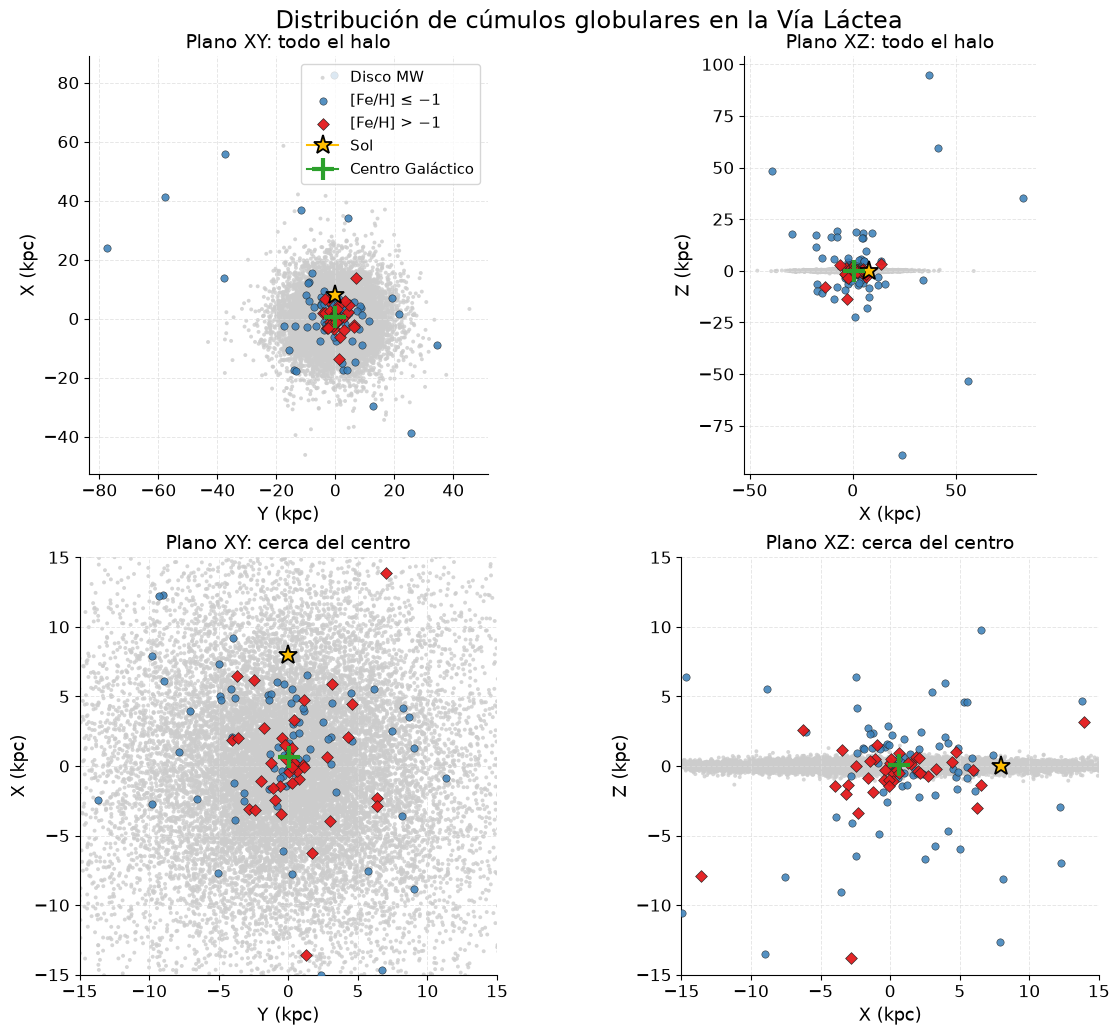


===== Cúmulos globulares =====
Cúmulos usados:               145
Centro (mediana):             (0.64, 0.04, 0.10) kpc
Sol:                          (8, 0, 0) kpc
Distancia del centro al Sol:  7.4 kpc
Metálicos [Fe/H] > −1:        n =  39    R = 3.0 kpc    |Z| = 0.8 kpc
Pobres [Fe/H] ≤ −1:           n = 100    R = 7.3 kpc    |Z| = 2.8 kpc



In [39]:
R0 = 8.0  # kpc
filas = []
patron = re.compile(
    r"^(?P<nombre>.+?)\s+\d+\s+\d+\s+[\d.]+\s+[+-]?\d+\s+\d+\s+\d+\s+(?P<resto>.*)$"
)
for linea in open(CARPETA / "data" / "GCs_MW.csv"):
    if linea.startswith("#") or not linea.strip():
        continue
    m = patron.match(linea.strip())
    numeros = [float(v) for v in m.group("resto").split()]
    if len(numeros) < 4:
        continue
    longitud, latitud, rsun = numeros[:3]
    if len(numeros) == 5 and numeros[4] < 0:
        metal = numeros[4]
    elif len(numeros) >= 6:
        metal = numeros[5]
    else:
        metal = np.nan
    filas.append((m.group("nombre").strip(), longitud, latitud, rsun, metal))

nombre = np.array([f[0] for f in filas])
longitud = np.deg2rad([f[1] for f in filas])
latitud = np.deg2rad([f[2] for f in filas])
rsun = np.array([f[3] for f in filas])
metal = np.array([f[4] for f in filas])

X = R0 - rsun * np.cos(latitud) * np.cos(longitud)
Y = rsun * np.cos(latitud) * np.sin(longitud)
Z = rsun * np.sin(latitud)
centro = np.array([np.median(X), np.median(Y), np.median(Z)])
sol = np.array([R0, 0.0, 0.0])
distancia = np.linalg.norm(centro - sol)
R = np.sqrt(X ** 2 + Y ** 2 + Z ** 2)

disco = np.loadtxt(CARPETA / "data" / "disquito.dat")
rica = metal > -1
pobre = metal <= -1

mpl.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False, "axes.labelsize": 13,
    "xtick.labelsize": 12, "ytick.labelsize": 12,
    "legend.fontsize": 11, "axes.titlesize": 14,
})

# Professionally-tuned marker/label colors and edge lines
color_disco = "#cccccc"
color_rica = "#e41a1c"   # Color C3 in default
color_pobre = "#377eb8"  # Color C0 in default
edgecolor = "#222222"

fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=100, constrained_layout=True)
paneles = (
    (axes[0, 0], Y, X, disco[:, 1], disco[:, 0], sol[1], sol[0], centro[1], centro[0], "Y (kpc)", "X (kpc)", None),
    (axes[0, 1], X, Z, disco[:, 0], disco[:, 2], sol[0], sol[2], centro[0], centro[2], "X (kpc)", "Z (kpc)", None),
    (axes[1, 0], Y, X, disco[:, 1], disco[:, 0], sol[1], sol[0], centro[1], centro[0], "Y (kpc)", "X (kpc)", 15),
    (axes[1, 1], X, Z, disco[:, 0], disco[:, 2], sol[0], sol[2], centro[0], centro[2], "X (kpc)", "Z (kpc)", 15),
)

for i, (ax, horizontal, vertical, disco_h, disco_v, sol_h, sol_v, cen_h, cen_v, etiqueta_h, etiqueta_v, zoom) in enumerate(paneles):
    # Plot 'disk' particles
    ax.scatter(
        disco_h, disco_v, s=8, c=color_disco, alpha=0.8, edgecolors="none", rasterized=True, label="Disco MW" if i == 0 else None,
    )
    # Plot metal-poor clusters
    ax.scatter(
        horizontal[pobre], vertical[pobre], s=28, c=color_pobre, edgecolors=edgecolor,
        marker="o", label="[Fe/H] ≤ −1",
        linewidth=0.4, alpha=0.85, zorder=3,
    )
    # Plot metal-rich clusters
    ax.scatter(
        horizontal[rica], vertical[rica], s=36, c=color_rica, edgecolors=edgecolor,
        marker="D", label="[Fe/H] > −1",
        linewidth=0.5, alpha=0.95, zorder=4,
    )
    # Plot Sun and center
    ax.plot(sol_h, sol_v, marker='*', color='#ffbe00', ms=14, mec='k', mew=1.3, label="Sol", zorder=6)
    ax.plot(cen_h, cen_v, marker='+', color='#2ca02c', ms=16, mew=3, label="Centro Galáctico", zorder=7)

    ax.set_xlabel(etiqueta_h)
    ax.set_ylabel(etiqueta_v)
    ax.set_aspect("equal")
    if zoom is not None:
        ax.set_xlim(-zoom, zoom)
        ax.set_ylim(-zoom, zoom)
    ax.grid(visible=True, color="#dddddd", linestyle="--", linewidth=0.7, alpha=0.7)
    # Remove duplicate labels
    handles, labels = ax.get_legend_handles_labels()
    new = OrderedDict()
    for h, l in zip(handles, labels):
        if l not in new: new[l] = h
    if i == 0:
        ax.legend(new.values(), new.keys(), loc="upper right", frameon=True, facecolor="white", edgecolor="#cccccc", fontsize=11)

axes[0, 0].set_title("Plano XY: todo el halo")
axes[0, 1].set_title("Plano XZ: todo el halo")
axes[1, 0].set_title("Plano XY: cerca del centro")
axes[1, 1].set_title("Plano XZ: cerca del centro")

fig.suptitle("Distribución de cúmulos globulares en la Vía Láctea", fontsize=17, y=1.02)
plt.show()

print("\n===== Cúmulos globulares =====")
print(f"Cúmulos usados:               {len(filas)}")
print(f"Centro (mediana):             ({centro[0]:.2f}, {centro[1]:.2f}, {centro[2]:.2f}) kpc")
print(f"Sol:                          ({sol[0]:.0f}, 0, 0) kpc")
print(f"Distancia del centro al Sol:  {distancia:.1f} kpc")
print(f"Metálicos [Fe/H] > −1:        n = {(metal > -1).sum():3d}    R = {np.median(R[metal > -1]):.1f} kpc    |Z| = {np.median(np.abs(Z[metal > -1])):.1f} kpc")
print(f"Pobres [Fe/H] ≤ −1:           n = {(metal <= -1).sum():3d}    R = {np.median(R[metal <= -1]):.1f} kpc    |Z| = {np.median(np.abs(Z[metal <= -1])):.1f} kpc")
print("============================\n")


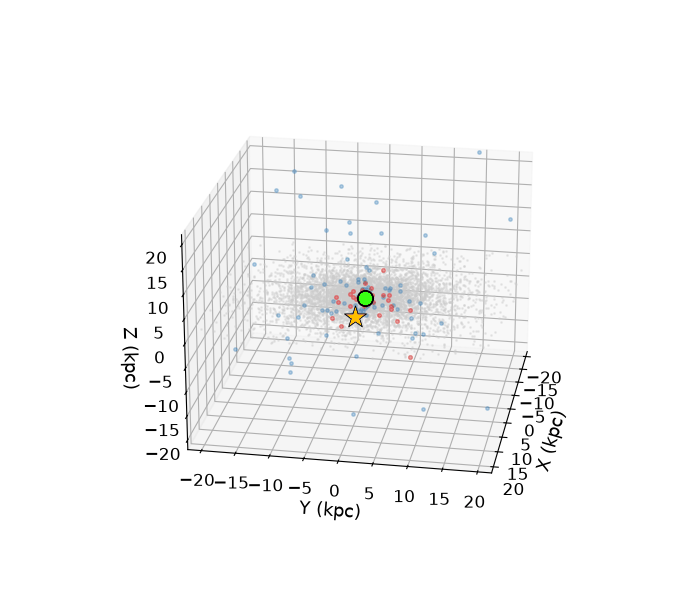

In [40]:

vista = 22
cerca = (np.abs(disco[:, 0]) < vista) & (np.abs(disco[:, 1]) < vista)
muestra = disco[cerca][::3]
fig_gif, ax = plt.subplots(figsize=(7, 6), subplot_kw={"projection": "3d", "computed_zorder": False})

def cuadro(angulo):
    ax.cla()
    ax.scatter(muestra[:, 0], muestra[:, 1], muestra[:, 2], s=1, c="#cccccc", alpha=0.35, depthshade=False, zorder=1)
    ax.scatter(X[pobre], Y[pobre], Z[pobre], s=6, c="#377eb8", alpha=0.35, depthshade=False, zorder=2)
    ax.scatter(X[rica], Y[rica], Z[rica], s=7, c="#e41a1c", alpha=0.4, depthshade=False, zorder=3)
    ax.scatter([sol[0]], [sol[1]], [sol[2]], s=280, c="#ffbe00", marker="*", edgecolors="k", linewidths=0.6, depthshade=False, zorder=5)
    # El centro va más grande que los cúmulos para que no se pierda en el disco.
    ax.scatter([centro[0]], [centro[1]], [centro[2]], s=120, c="#39ff14", marker="o", edgecolors="k", linewidths=1.4, depthshade=False, zorder=6)
    ax.set_xlim(-vista, vista)
    ax.set_ylim(-vista, vista)
    ax.set_zlim(-vista, vista)
    ax.set_xlabel("X (kpc)")
    ax.set_ylabel("Y (kpc)")
    ax.set_zlabel("Z (kpc)")
    ax.view_init(elev=22, azim=angulo)

anim = FuncAnimation(fig_gif, cuadro, frames=np.linspace(10, 200, 60), blit=False)
ruta_gif = CARPETA / "figuras" / "cumulos_3d.gif"
anim.save(ruta_gif, writer=PillowWriter(fps=6))
plt.close(fig_gif)

display(Image(filename=str(ruta_gif)))


##### El centro no está en el Sol

El Sol está en $(8,\,0,\,0)$ kpc. La mediana de los cúmulos cae cerca de $(0.64,\,0,\,0)$, pegada al centro de la Galaxia, no al Sol. La distancia entre esos dos puntos es unos 7.4 kpc. Si los cúmulos rodearan al Sol, la mediana caería en $(8,\,0,\,0)$.

Se usa la mediana y no el promedio porque unos pocos cúmulos del halo, a más de 80 kpc, arrastran el promedio.


##### Metalicidad

El corte $[\mathrm{Fe}/\mathrm{H}] = -1$ separa dos grupos.

Los más ricos, $[\mathrm{Fe}/\mathrm{H}] > -1$, viven cerca del centro y cerca del plano: mediana de $R \approx 3$ kpc y de $|Z| \approx 0.8$ kpc. Acompañan al bulbo y al disco interior.

Los pobres, $[\mathrm{Fe}/\mathrm{H}] \le -1$, forman un halo más redondo y más grande: mediana de $R \approx 7$ kpc y de $|Z| \approx 3$ kpc. Se ven por encima y por debajo del disco en la vista de canto.

El disco gris es delgado. Los cúmulos ricos se le pegan. Los pobres lo atraviesan.

---

##### Referencias

Carroll, B. W. y Ostlie, D. A. (2007). *An Introduction to Modern Astrophysics* (2.ª ed.). Pearson. Ecuaciones 25.3 y 25.7, tabla 25.1.

de Vaucouleurs, G., de Vaucouleurs, A., Corwin, H. G., Buta, R. J., Paturel, G. y Fouqué, P. (1991). *Third Reference Catalogue of Bright Galaxies*. Springer.

Dey, A., Schlegel, D. J., Lang, D., et al. (2019). Overview of the DESI Legacy Imaging Surveys. *Astronomical Journal*, 157, 168. https://doi.org/10.3847/1538-3881/ab089d

Holmberg, E. (1946). On the apparent distributions of stars. *Meddelanden från Lunds Astronomiska Observatorium*, Serie II, N.º 117.

Hubble, E. (1926). Extragalactic nebulae. *Astrophysical Journal*, 64, 321.

Oke, J. B. y Gunn, J. E. (1983). Secondary standard stars for absolute spectrophotometry. *Astrophysical Journal*, 266, 713.

Shapley, H. (1918). Studies based on the colors and magnitudes in stellar clusters. Seventh paper. *Astrophysical Journal*, 48, 154.

York, D. G., Adelman, J., Anderson, J. E., et al. (2000). The Sloan Digital Sky Survey: Technical summary. *Astronomical Journal*, 120, 1579. https://doi.org/10.1086/301513

Imagen de NGC 2403, banda g: repositorio de Monash University, https://store.erc.monash.edu.au/dataset/417

Phookun, B., Vogel, S. N. y Mundy, L. G. (1993). NGC 4254: a spiral galaxy with an m = 1 mode. *Astrophysical Journal*, 418, 113.

Chyży, K. T. (2008). Magnetic fields and gas in the cluster-influenced spiral galaxy NGC 4254. *Astronomy and Astrophysics*, 482, 755.

Para el desarrollo de algunas partes de este notebook, se empleó Cursor como asistente de inteligencia artificial. Cursor facilitó la conceptualización, la codificación y la depuración de secciones relevantes del trabajo.